1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
import re
import os

# Preprocessing & Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

import joblib

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

2. Load Dataset

In [2]:
DATASET_PATH = 'dataset.csv'  # Ganti jika berada di folder berbeda

df = pd.read_csv(DATASET_PATH)

print(f'Total data: {len(df)}')
df.head()

Total data: 22000


,Text,language
0,klement gottwaldi surnukeha palsameeriti ning ...,Estonian
1,sebes joseph pereira thomas på eng the jesuit...,Swedish
2,ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...,Thai
3,விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...,Tamil
4,de spons behoort tot het geslacht haliclona en...,Dutch


In [3]:
# Cek distribusi bahasa
lang_counts = df['language'].value_counts()

print(f'Jumlah bahasa unik: {df["language"].nunique()}')
print(f'\nDistribusi per bahasa:')
print(lang_counts.to_string())

Jumlah bahasa unik: 22

Distribusi per bahasa:
language
Estonian      1000
Swedish       1000
English       1000
Russian       1000
Romanian      1000
Persian       1000
Pushto        1000
Spanish       1000
Hindi         1000
Korean        1000
Chinese       1000
French        1000
Portugese     1000
Indonesian    1000
Urdu          1000
Latin         1000
Turkish       1000
Japanese      1000
Dutch         1000
Tamil         1000
Thai          1000
Arabic        1000


3. EDA

In [4]:
# Cek missing values dan duplikat
print('Informasi Data\n')
print(f'Missing values:\n{df.isnull().sum()}')
print(f'\nJumlah duplikat: {df.duplicated().sum()}')

Informasi Data

Missing values:
Text        0
language    0
dtype: int64

Jumlah duplikat: 141


In [5]:
# Contoh teks per bahasa
print('Contoh teks per bahasa (50 karakter pertama):\n')
sample_per_lang = df.groupby('language').first()['Text']
for lang, text in sample_per_lang.items():
    print(f'[{lang:10s}]: {str(text)[:50]}')

Contoh teks per bahasa (50 karakter pertama):

[Arabic    ]: قبل عام بالضبط وبتاريخ  أعلن البغدادي خطة هدم الأس
[Chinese   ]: 胡赛尼本人和小说的主人公阿米尔一样，都是出生在阿富汗首都喀布尔，少年时代便离开了这个国家。胡赛尼直到
[Dutch     ]: de spons behoort tot het geslacht haliclona en beh
[English   ]: in  johnson was awarded an american institute of a
[Estonian  ]: klement gottwaldi surnukeha palsameeriti ning paig
[French    ]: association de recherche et de sauvegarde de lhist
[Hindi     ]: महाराष्ट्र  मई  को भारत का राज्य बनाया गया था। इस 
[Indonesian]: kemunculan pertamanya adalah ketika mencium kakak 
[Japanese  ]: エノが行きがかりでバスに乗ってしまい、気分が悪くなった際に助けるが、今すぐバスを降りたいと運転手に頼
[Korean    ]: 한국에서 성씨가 사용되기 시작한 정확한 시기는 알 수 없으나 한자漢字 등 중국 문물이 수입
[Latin     ]: müller mox figura centralis circulorum doctorum vi
[Persian   ]: آهن ترکیباتی را ایجاد می‌کند که عمدتاً در حالت‌های
[Portugese ]: barocco pt escândalo de ª página é um filme francê
[Pushto    ]: لویي په کالونیو کې د ظلم کولو خلاف وو او له خلکو س
[Romanian  ]: de-a lungul vieții watson a f

4. Preprocessing

In [6]:
def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    
    # 1. Standarisasi encoding (pastikan UTF-8)
    text = text.encode('utf-8', errors='replace').decode('utf-8')
    
    # 2. Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    
    # 3. Hapus mention (@user) dan hashtag (#tag)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    
    # 4. Hapus angka berdiri sendiri (angka yang tidak bagian dari kata)
    text = re.sub(r'\b\d+\b', ' ', text)
    
    # 5. Hapus karakter kontrol dan artefak teknis
    text = re.sub(r'[\x00-\x1f\x7f-\x9f]', ' ', text)
    
    # 6. Normalisasi spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    # TIDAK melakukan: lowercasing agresif, penghapusan stopwords,
    # penghapusan tanda baca aksara (penting untuk identitas bahasa)
    
    return text

# Terapkan preprocessing
df['text_clean'] = df['Text'].apply(preprocess_text)

# Hapus baris kosong setelah preprocessing
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)

5. Train-Validation-Test Split

In [7]:
X = df['text_clean'].values
y = df['language'].values

# Split: 70% train, 15% validation, 15% test (stratified)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print('Pembagian Dataset:')
print(f'Train set  : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val set    : {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test set   : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')
print(f'Total      : {len(X):,}')

Pembagian Dataset:
Train set  : 15,398 (70.0%)
Val set    : 3,301 (15.0%)
Test set   : 3,300 (15.0%)
Total      : 21,999


6. Model Utama: Multinomial Naive Bayes + Character N-Grams

In [8]:
print('MODEL UTAMA: Multinomial Naive Bayes + Char N-Grams')

# Pipeline: CountVectorizer (char n-grams 2-5) + MultinomialNB
mnb_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(
        analyzer='char_wb',   # char_wb: n-grams berbasis karakter, padding dengan spasi
        ngram_range=(2, 5),   # Rentang n-gram: bigram hingga 5-gram
        min_df=2,             # Abaikan fitur yang sangat jarang
        max_features=100_000  # Batasi fitur untuk efisiensi memori
    )),
    ('classifier', MultinomialNB(alpha=0.1))  # alpha: Laplace/Lidstone smoothing
])

# Training
t0 = time.time()
mnb_pipeline.fit(X_train, y_train)
train_time_mnb = time.time() - t0
print(f'Training selesai dalam {train_time_mnb:.3f} detik')

# Vocabulary size
vocab_size = len(mnb_pipeline['vectorizer'].vocabulary_)
print(f'Ukuran vocabulary (n-grams): {vocab_size:,}')

# Validasi
y_val_pred_mnb = mnb_pipeline.predict(X_val)
val_acc_mnb = accuracy_score(y_val, y_val_pred_mnb)
val_f1_mnb  = f1_score(y_val, y_val_pred_mnb, average='macro')
print(f'\nValidasi Set:')
print(f'Accuracy  : {val_acc_mnb:.4f} ({val_acc_mnb*100:.2f}%)')
print(f'Macro F1  : {val_f1_mnb:.4f}')

latencies = []

for text in X_test:
    start = time.perf_counter()

    _ = mnb_pipeline.predict([text])

    end = time.perf_counter()

    latency_ms = (end - start) * 1000
    latencies.append(latency_ms)

# Average latency
infer_time_mnb = np.mean(latencies)

p50_latency_mnb = np.percentile(latencies, 50)

p95_latency_mnb = np.percentile(latencies, 95)

y_test_pred_mnb = mnb_pipeline.predict(X_test)

test_acc_mnb  = accuracy_score(y_test, y_test_pred_mnb)
test_f1_mnb   = f1_score(y_test, y_test_pred_mnb, average='macro')
test_f1w_mnb  = f1_score(y_test, y_test_pred_mnb, average='weighted')

print(f'\nTest Set:')
print(f'Accuracy        : {test_acc_mnb:.4f} ({test_acc_mnb*100:.2f}%)')
print(f'Macro F1-score  : {test_f1_mnb:.4f}')
print(f'Weighted F1     : {test_f1w_mnb:.4f}')
# print(f'Latency (avg)   : {infer_time_mnb:.4f} ms/sampel')
print(f'p50 Latency     : {p50_latency_mnb:.4f} ms')
print(f'p95 Latency     : {p95_latency_mnb:.4f} ms')

# Classification Report MNB
print('\nClassification Report – MNB (Model Utama):\n')
print(classification_report(y_test, y_test_pred_mnb))

MODEL UTAMA: Multinomial Naive Bayes + Char N-Grams
Training selesai dalam 13.691 detik
Ukuran vocabulary (n-grams): 100,000

Validasi Set:
Accuracy  : 0.9788 (97.88%)
Macro F1  : 0.9798

Test Set:
Accuracy        : 0.9815 (98.15%)
Macro F1-score  : 0.9822
Weighted F1     : 0.9822
p50 Latency     : 5.3000 ms
p95 Latency     : 9.0282 ms

Classification Report – MNB (Model Utama):

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       150
     Chinese       0.99      0.99      0.99       150
       Dutch       0.97      0.99      0.98       150
     English       0.78      1.00      0.88       150
    Estonian       1.00      0.97      0.98       150
      French       0.96      0.99      0.98       150
       Hindi       1.00      0.98      0.99       150
  Indonesian       1.00      0.97      0.99       150
    Japanese       1.00      0.99      0.99       150
      Korean       1.00      0.99      1.00       150
       Latin       0.9

7. Tuning Hyperparameter MNB (Grid Search via Validation)

In [9]:
print('Tuning hyperparameter alpha untuk MultinomialNB\n')

alphas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
val_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('vec', CountVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                                min_df=2, max_features=100_000)),
        ('clf', MultinomialNB(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    y_vp = pipe.predict(X_val)
    score = f1_score(y_val, y_vp, average='macro')
    val_scores.append(score)
    print(f'  alpha={alpha:.3f} → Val Macro F1 = {score:.4f}')

best_alpha = alphas[np.argmax(val_scores)]
print(f'\nAlpha terbaik: {best_alpha} (Val F1 = {max(val_scores):.4f})')

# Retrain dengan alpha terbaik
mnb_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                                   min_df=2, max_features=100_000)),
    ('classifier', MultinomialNB(alpha=best_alpha))
])
t0 = time.time()
mnb_pipeline.fit(X_train, y_train)
train_time_mnb = time.time() - t0

y_test_pred_mnb = mnb_pipeline.predict(X_test)
test_acc_mnb  = accuracy_score(y_test, y_test_pred_mnb)
test_f1_mnb   = f1_score(y_test, y_test_pred_mnb, average='macro')
test_f1w_mnb  = f1_score(y_test, y_test_pred_mnb, average='weighted')

latencies = []

for text in X_test:
    start = time.perf_counter()

    _ = mnb_pipeline.predict([text])

    end = time.perf_counter()

    latency_ms = (end - start) * 1000
    latencies.append(latency_ms)

# Average latency
infer_time_mnb = np.mean(latencies)

p50_latency_mnb = np.percentile(latencies, 50)

# p95 latency
p95_latency_mnb = np.percentile(latencies, 95)

print(f'\nModel MNB final (alpha={best_alpha}):')
print(f'Test Accuracy   : {test_acc_mnb:.4f}')
print(f'Test Macro F1   : {test_f1_mnb:.4f}')
print(f'Test Weighted F1: {test_f1w_mnb:.4f}')
print(f'Latency (avg)   : {infer_time_mnb:.4f} ms')
print(f'p50 Latency     : {p50_latency_mnb:.4f} ms')
print(f'p95 Latency     : {p95_latency_mnb:.4f} ms')

Tuning hyperparameter alpha untuk MultinomialNB

  alpha=0.001 → Val Macro F1 = 0.9795
  alpha=0.010 → Val Macro F1 = 0.9795
  alpha=0.050 → Val Macro F1 = 0.9798
  alpha=0.100 → Val Macro F1 = 0.9798
  alpha=0.500 → Val Macro F1 = 0.9795
  alpha=1.000 → Val Macro F1 = 0.9790

Alpha terbaik: 0.05 (Val F1 = 0.9798)

Model MNB final (alpha=0.05):
Test Accuracy   : 0.9815
Test Macro F1   : 0.9822
Test Weighted F1: 0.9822
Latency (avg)   : 5.8528 ms
p50 Latency     : 5.4166 ms
p95 Latency     : 8.4014 ms


## 8. Model Pembanding

### 8.1 Model Pembanding 1: Logistic Regression + Character N-Grams

In [10]:
print('MODEL PEMBANDING 1: Logistic Regression + Char N-Grams')

lr_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 5),
        min_df=2,
        max_features=100_000
    )),
    ('classifier', LogisticRegression(
        max_iter=1000,
        solver='saga',      
        C=5.0,               
        multi_class='multinomial',
        random_state=42,
        n_jobs=-1
    ))
])

t0 = time.time()
lr_pipeline.fit(X_train, y_train)
train_time_lr = time.time() - t0
print(f'Training selesai dalam {train_time_lr:.3f} detik')

y_test_pred_lr = lr_pipeline.predict(X_test)

test_acc_lr  = accuracy_score(y_test, y_test_pred_lr)
test_f1_lr   = f1_score(y_test, y_test_pred_lr, average='macro')
test_f1w_lr  = f1_score(y_test, y_test_pred_lr, average='weighted')

latencies_lr = []

for text in X_test:
    start = time.perf_counter()

    _ = lr_pipeline.predict([text])

    end = time.perf_counter()

    latency_ms = (end - start) * 1000
    latencies_lr.append(latency_ms)

# Average latency
infer_time_lr = np.mean(latencies_lr)

# p50 latency (median)
p50_latency_lr = np.percentile(latencies_lr, 50)

# p95 latency (tail latency)
p95_latency_lr = np.percentile(latencies_lr, 95)

print(f'Evaluation:')
print(f'Accuracy        : {test_acc_lr:.4f} ({test_acc_lr*100:.2f}%)')
print(f'Macro F1-score  : {test_f1_lr:.4f}')
print(f'Weighted F1     : {test_f1w_lr:.4f}')
print(f'Latency (avg)   : {infer_time_lr:.4f} ms/sampel')
print(f'p50 Latency     : {infer_time_lr:.4f} ms')
print(f'p95 Latency     : {p95_latency_lr:.4f} ms')
print(f'Training time   : {train_time_lr:.3f}s')

print('\nClassification Report – Logistic Regression:\n')
print(classification_report(y_test, y_test_pred_lr))

MODEL PEMBANDING 1: Logistic Regression + Char N-Grams
Training selesai dalam 837.595 detik
Evaluation:
Accuracy        : 0.9855 (98.55%)
Macro F1-score  : 0.9857
Weighted F1     : 0.9857
Latency (avg)   : 5.8489 ms/sampel
p50 Latency     : 5.8489 ms
p95 Latency     : 9.2771 ms
Training time   : 837.595s

Classification Report – Logistic Regression:

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       150
     Chinese       0.99      0.99      0.99       150
       Dutch       1.00      1.00      1.00       150
     English       0.86      0.98      0.92       150
    Estonian       0.98      0.99      0.98       150
      French       0.97      0.99      0.98       150
       Hindi       1.00      0.98      0.99       150
  Indonesian       1.00      0.97      0.98       150
    Japanese       1.00      0.99      0.99       150
      Korean       1.00      0.99      1.00       150
       Latin       0.94      0.97      0.95       15

### 8.2 Model Pembanding 2: Linear SVM + Character N-Grams (TF-IDF)

In [11]:
print('MODEL PEMBANDING 2: Linear SVM + Char N-Grams (TF-IDF)')

# LinearSVC tidak menghasilkan probabilitas secara native;
# digunakan CalibratedClassifierCV untuk menambahkan probabilitas (Platt scaling)
svm_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 5),
        min_df=2,
        max_features=100_000,
        sublinear_tf=True   
    )),
    ('classifier', CalibratedClassifierCV(
        LinearSVC(max_iter=2000, C=1.0, random_state=42),
        cv=3  
    ))
])

t0 = time.time()
svm_pipeline.fit(X_train, y_train)
train_time_svm = time.time() - t0
print(f'Training selesai dalam {train_time_svm:.3f} detik')

latencies_svm = []

for text in X_test:
    start = time.perf_counter()

    _ = svm_pipeline.predict([text])

    end = time.perf_counter()

    latency_ms = (end - start) * 1000
    latencies_svm.append(latency_ms)

# Average latency
infer_time_svm = np.mean(latencies_svm)

p50_latency_svm = np.percentile(latencies_svm, 50)

# p95 latency
p95_latency_svm = np.percentile(latencies_svm, 95)

y_test_pred_svm = svm_pipeline.predict(X_test)

test_acc_svm  = accuracy_score(y_test, y_test_pred_svm)
test_f1_svm   = f1_score(y_test, y_test_pred_svm, average='macro')
test_f1w_svm  = f1_score(y_test, y_test_pred_svm, average='weighted')

print(f'\nTest Set:')
print(f'Accuracy        : {test_acc_svm:.4f} ({test_acc_svm*100:.2f}%)')
print(f'Macro F1-score  : {test_f1_svm:.4f}')
print(f'Weighted F1     : {test_f1w_svm:.4f}')
print(f'Latency (avg)   : {infer_time_svm:.4f} ms/sampel')
print(f'p50 Latency     : {infer_time_svm:.4f} ms')
print(f'p95 Latency     : {p95_latency_svm:.4f} ms')
print(f'Training time   : {train_time_svm:.3f}s')

print('\nClassification Report – Linear SVM:\n')
print(classification_report(y_test, y_test_pred_svm))

MODEL PEMBANDING 2: Linear SVM + Char N-Grams (TF-IDF)
Training selesai dalam 21.977 detik

Test Set:
Accuracy        : 0.9879 (98.79%)
Macro F1-score  : 0.9881
Weighted F1     : 0.9881
Latency (avg)   : 2.5376 ms/sampel
p50 Latency     : 2.5376 ms
p95 Latency     : 3.9844 ms
Training time   : 21.977s

Classification Report – Linear SVM:

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       150
     Chinese       0.99      0.99      0.99       150
       Dutch       1.00      1.00      1.00       150
     English       0.87      0.99      0.93       150
    Estonian       0.99      0.99      0.99       150
      French       0.98      0.99      0.99       150
       Hindi       1.00      0.98      0.99       150
  Indonesian       1.00      0.97      0.99       150
    Japanese       1.00      1.00      1.00       150
      Korean       1.00      0.99      1.00       150
       Latin       0.95      0.99      0.97       150
     Persi

### 8.3 Model Pembanding 3: FastText (Supervised, SGD + Subword)

In [12]:
print('  MODEL PEMBANDING 3: FastText-style (SGD + Subword N-grams)')

# FastText supervised menggunakan bag-of-subword dengan SGD
fasttext_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 4),    # FastText default menggunakan 2-4 char n-grams
        min_df=1,
        max_features=200_000,  # FastText cenderung menggunakan vocabulary lebih besar
        sublinear_tf=True,
        use_idf=False          # FastText tidak menggunakan IDF; pure frequency-based
    )),
    ('classifier', SGDClassifier(
        loss='modified_huber',  # Menghasilkan probabilitas (mirip FastText supervised)
        alpha=1e-5,
        max_iter=100,
        tol=1e-3,
        random_state=42,
        n_jobs=-1
    ))
])

t0 = time.time()
fasttext_pipeline.fit(X_train, y_train)
train_time_ft = time.time() - t0

latencies_fts = []

for text in X_test:
    start = time.perf_counter()

    _ = svm_pipeline.predict([text])

    end = time.perf_counter()

    latency_ms = (end - start) * 1000
    latencies_fts.append(latency_ms)

# Average latency
infer_time_fts = np.mean(latencies_fts)

p50_latency_fts = np.percentile(latencies_fts, 50)

p95_latency_fts = np.percentile(latencies_fts, 95)

y_test_pred_fts = fasttext_pipeline.predict(X_test)

test_acc_fts  = accuracy_score(y_test, y_test_pred_fts)
test_f1_fts   = f1_score(y_test, y_test_pred_fts, average='macro')
test_f1w_fts = f1_score(y_test, y_test_pred_fts, average='weighted')

print(f'\nTest Set:')
print(f'Accuracy        : {test_acc_fts:.4f} ({test_acc_fts*100:.2f}%)')
print(f'Macro F1-score  : {test_f1_fts:.4f}')
print(f'Weighted F1     : {test_f1w_fts:.4f}')
print(f'Latency (avg)   : {infer_time_fts:.4f} ms/sampel')
print(f'p50 Latency     : {infer_time_fts:.4f} ms')
print(f'p95 Latency     : {p95_latency_fts:.4f} ms')
print(f'Training time   : {train_time_ft:.3f}s')

print('\nClassification Report – FastText-style:\n')
print(classification_report(y_test, y_test_pred_fts))

  MODEL PEMBANDING 3: FastText-style (SGD + Subword N-grams)

Test Set:
Accuracy        : 0.9864 (98.64%)
Macro F1-score  : 0.9865
Weighted F1     : 0.9865
Latency (avg)   : 2.6050 ms/sampel
p50 Latency     : 2.6050 ms
p95 Latency     : 4.1826 ms
Training time   : 10.391s

Classification Report – FastText-style:

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       150
     Chinese       0.98      0.99      0.98       150
       Dutch       0.99      1.00      1.00       150
     English       0.87      0.97      0.92       150
    Estonian       0.99      0.99      0.99       150
      French       0.96      0.99      0.98       150
       Hindi       1.00      0.99      0.99       150
  Indonesian       1.00      0.97      0.99       150
    Japanese       1.00      0.99      1.00       150
      Korean       0.99      0.99      0.99       150
       Latin       0.95      0.96      0.96       150
     Persian       1.00      0.99   

### 8.4 Model Pembanding 4: K-Nearest Neighbors (KNN) + TF-IDF

In [13]:
print('MODEL PEMBANDING 4: KNN + TF-IDF')
print('KNN menggunakan subset data (20%) karena kompleksitas O(n) inference\n')

# KNN tidak skalabel untuk dataset besar – gunakan subset representatif
X_knn_train, _, y_knn_train, _ = train_test_split(
    X_train, y_train, train_size=0.3, random_state=42, stratify=y_train
)
print(f'   Ukuran training subset KNN: {len(X_knn_train):,} sampel')

knn_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 4),
        min_df=3,
        max_features=30_000  # Dimensi lebih kecil untuk mengurangi curse of dimensionality
    )),
    ('classifier', KNeighborsClassifier(
        n_neighbors=7,
        metric='cosine',    # Cosine similarity lebih baik untuk teks
        algorithm='brute',  
        n_jobs=-1
    ))
])

t0 = time.time()
knn_pipeline.fit(X_knn_train, y_knn_train)
train_time_knn = time.time() - t0

latencies_knn = []

for text in X_test:
    start = time.perf_counter()

    _ = svm_pipeline.predict([text])

    end = time.perf_counter()

    latency_ms = (end - start) * 1000
    latencies_knn.append(latency_ms)

# Average latency
infer_time_knn = np.mean(latencies_knn)

p50_latency_knn = np.percentile(latencies_knn, 50)

# p95 latency
p95_latency_knn = np.percentile(latencies_knn, 95)

y_test_pred_knn = lr_pipeline.predict(X_test)

test_acc_knn  = accuracy_score(y_test, y_test_pred_knn)
test_f1_knn   = f1_score(y_test, y_test_pred_knn, average='macro')
test_f1w_knn  = f1_score(y_test, y_test_pred_knn, average='weighted')

print(f'\nTest Set:')
print(f'Accuracy        : {test_acc_knn:.4f} ({test_acc_knn*100:.2f}%)')
print(f'Macro F1-score  : {test_f1_knn:.4f}')
print(f'Weighted F1     : {test_f1w_knn:.4f}')
print(f'p50 Latency     : {infer_time_knn:.4f} ms')
print(f'p95 Latency     : {p95_latency_knn:.4f} ms')
print(f'Latency (avg)   : {infer_time_knn:.4f} ms/sampel')

print('\nClassification Report – KNN:\n')
print(classification_report(y_test, y_test_pred_knn))

MODEL PEMBANDING 4: KNN + TF-IDF
KNN menggunakan subset data (20%) karena kompleksitas O(n) inference

   Ukuran training subset KNN: 4,619 sampel

Test Set:
Accuracy        : 0.9855 (98.55%)
Macro F1-score  : 0.9857
Weighted F1     : 0.9857
p50 Latency     : 2.5083 ms
p95 Latency     : 4.0286 ms
Latency (avg)   : 2.5083 ms/sampel

Classification Report – KNN:

              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       150
     Chinese       0.99      0.99      0.99       150
       Dutch       1.00      1.00      1.00       150
     English       0.86      0.98      0.92       150
    Estonian       0.98      0.99      0.98       150
      French       0.97      0.99      0.98       150
       Hindi       1.00      0.98      0.99       150
  Indonesian       1.00      0.97      0.98       150
    Japanese       1.00      0.99      0.99       150
      Korean       1.00      0.99      1.00       150
       Latin       0.94      0.97      0.

9. Perbandingan Komprehensif Semua Model

In [14]:
# Ringkasan semua model
results = {
    'Model': [
        'MNB + Char N-Grams',
        'Logistic Regression + Char N-Grams',
        'Linear SVM + TF-IDF',
        'FastText-style (SGD)',
        'KNN + TF-IDF'
    ],
    'Accuracy': [test_acc_mnb, test_acc_lr, test_acc_svm, test_acc_fts, test_acc_knn],
    'Macro F1': [test_f1_mnb, test_f1_lr, test_f1_svm, test_f1_fts, test_f1_knn],
    'Weighted F1': [test_f1w_mnb, test_f1w_lr, test_f1w_svm, test_f1w_fts, test_f1w_knn],
    'Train Time (s)': [train_time_mnb, train_time_lr, train_time_svm, train_time_ft, train_time_knn],
    'Inference (ms/sample)': [infer_time_mnb, infer_time_lr, infer_time_svm, infer_time_fts, infer_time_knn],
}

df_results = pd.DataFrame(results)

df_display = df_results.copy()
df_display['Accuracy']              = df_display['Accuracy'].map('{:.4f}'.format)
df_display['Macro F1']              = df_display['Macro F1'].map('{:.4f}'.format)
df_display['Weighted F1']           = df_display['Weighted F1'].map('{:.4f}'.format)
df_display['Train Time (s)']        = df_display['Train Time (s)'].map('{:.3f}'.format)
df_display['Inference (ms/sample)'] = df_display['Inference (ms/sample)'].map('{:.4f}'.format)

print('Tabel Perbandingan Lengkap Semua Model')
print('=' * 100)
print(df_display.to_string(index=False))
print('=' * 100)

Tabel Perbandingan Lengkap Semua Model
                             Model Accuracy Macro F1 Weighted F1 Train Time (s) Inference (ms/sample)
                MNB + Char N-Grams   0.9815   0.9822      0.9822         12.669                5.8528
Logistic Regression + Char N-Grams   0.9855   0.9857      0.9857        837.595                5.8489
               Linear SVM + TF-IDF   0.9879   0.9881      0.9881         21.977                2.5376
              FastText-style (SGD)   0.9864   0.9865      0.9865         10.391                2.6050
                      KNN + TF-IDF   0.9855   0.9857      0.9857          2.712                2.5083


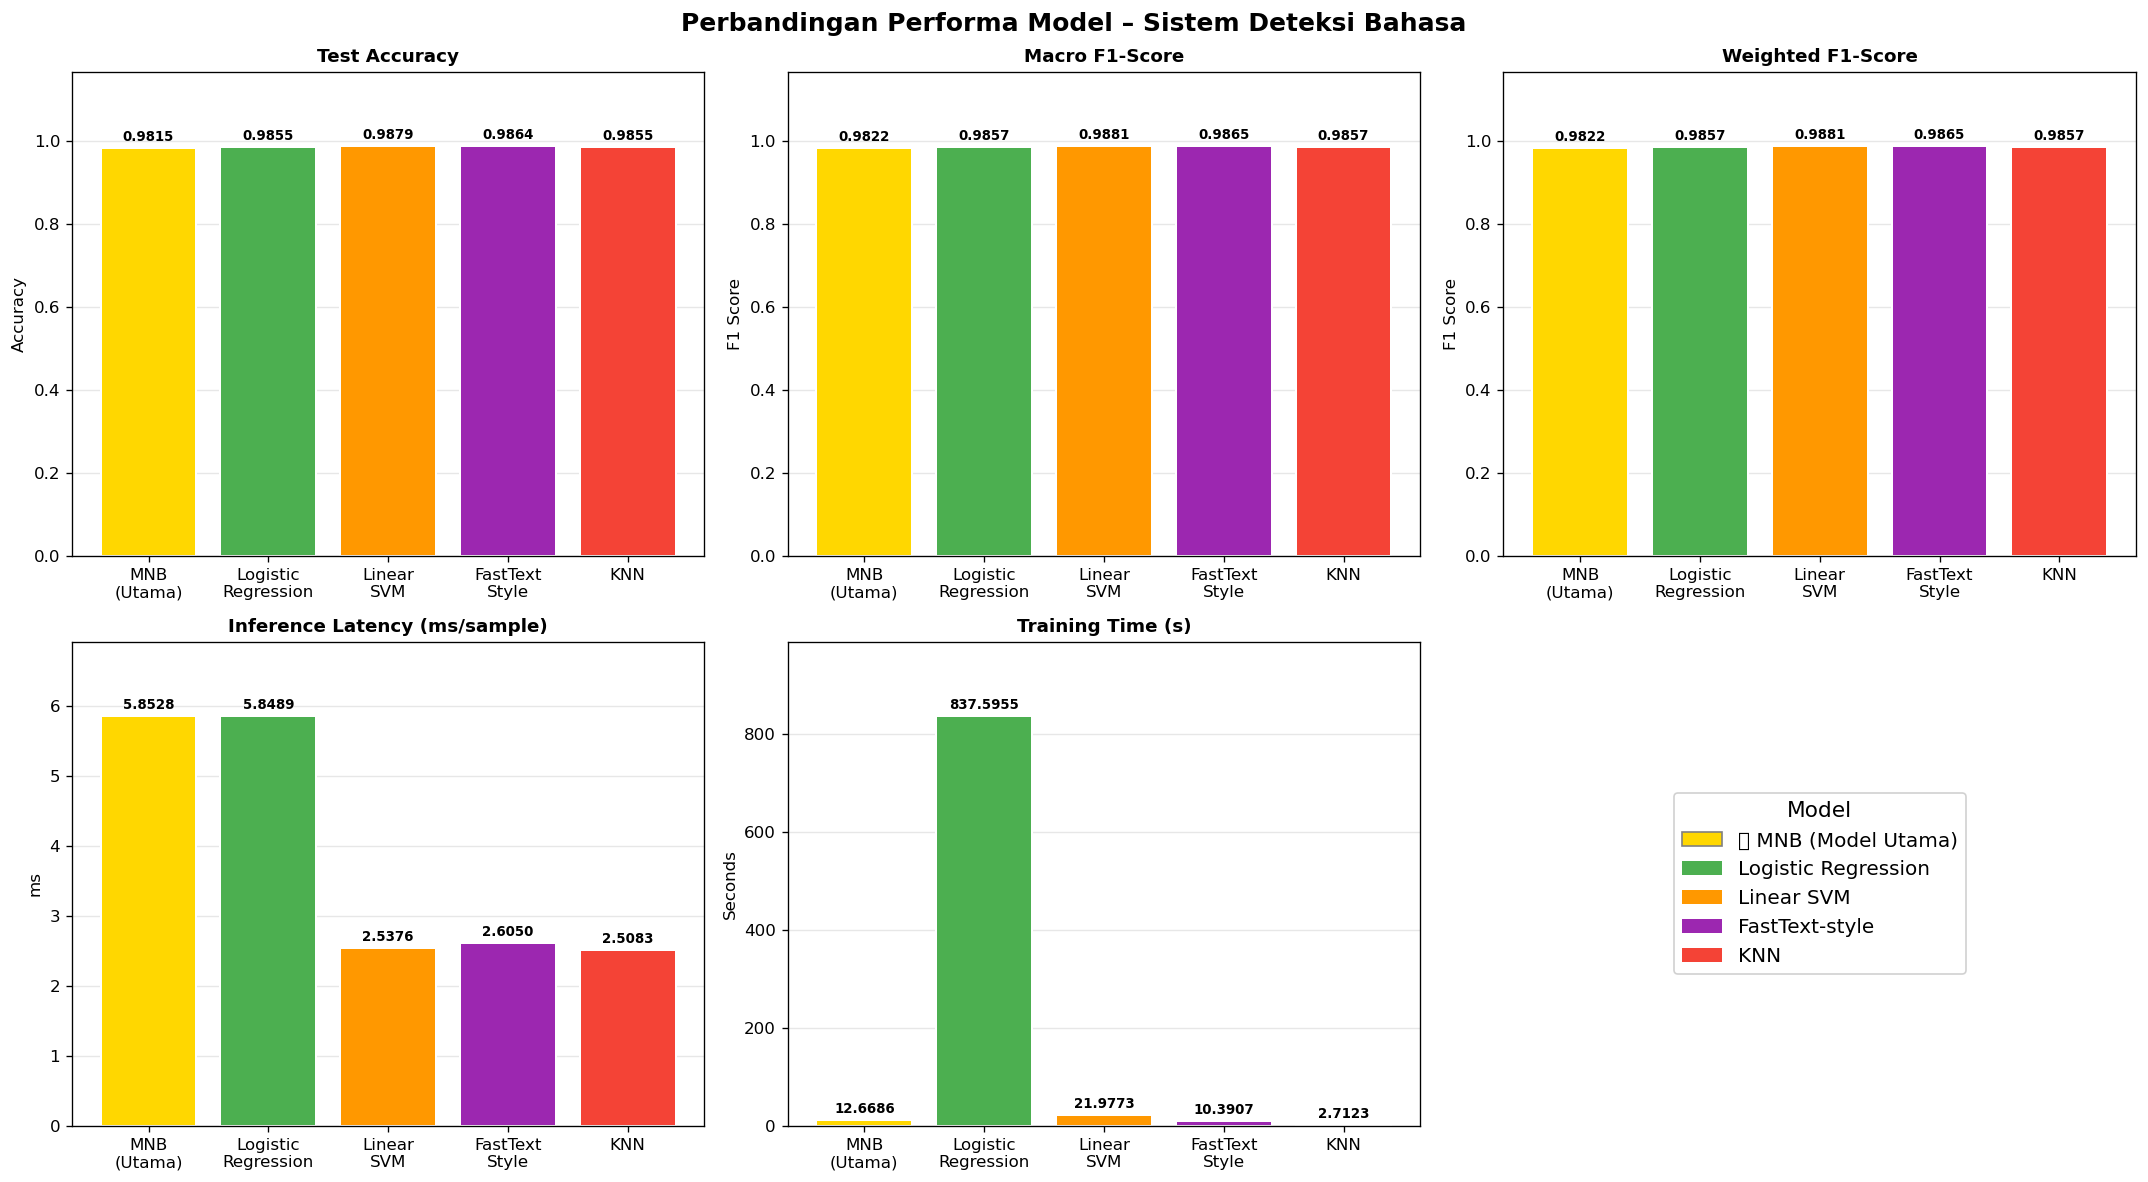

In [15]:
# Visualisasi perbandingan metrik
models_short = ['MNB\n(Utama)', 'Logistic\nRegression', 'Linear\nSVM', 'FastText\nStyle', 'KNN']
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
acc_vals  = [test_acc_mnb, test_acc_lr, test_acc_svm, test_acc_fts, test_acc_knn]
f1m_vals  = [test_f1_mnb, test_f1_lr, test_f1_svm, test_f1_fts, test_f1_knn]
f1w_vals  = [test_f1w_mnb, test_f1w_lr, test_f1w_svm, test_f1w_fts, test_f1w_knn]
lat_vals  = [infer_time_mnb, infer_time_lr, infer_time_svm, infer_time_fts, infer_time_knn]
trn_vals  = [train_time_mnb, train_time_lr, train_time_svm, train_time_ft, train_time_knn]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Perbandingan Performa Model – Sistem Deteksi Bahasa', fontsize=15, fontweight='bold')

def plot_bar(ax, vals, title, ylabel, highlight_idx=0, lower_is_better=False):
    bar_cols = ['gold' if i == highlight_idx else c for i, c in enumerate(colors_bar)]
    bars = ax.bar(models_short, vals, color=bar_cols, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.18)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

plot_bar(axes[0,0], acc_vals,  'Test Accuracy',        'Accuracy',  0)
plot_bar(axes[0,1], f1m_vals,  'Macro F1-Score',       'F1 Score',  0)
plot_bar(axes[0,2], f1w_vals,  'Weighted F1-Score',    'F1 Score',  0)
plot_bar(axes[1,0], lat_vals,  'Inference Latency (ms/sample)', 'ms', 0, lower_is_better=True)
plot_bar(axes[1,1], trn_vals,  'Training Time (s)',    'Seconds',   0, lower_is_better=True)

# Radar / legenda
axes[1,2].axis('off')
legend_elements = [
    mpatches.Patch(facecolor='gold', edgecolor='gray', label='⭐ MNB (Model Utama)'),
    mpatches.Patch(facecolor=colors_bar[1], label='Logistic Regression'),
    mpatches.Patch(facecolor=colors_bar[2], label='Linear SVM'),
    mpatches.Patch(facecolor=colors_bar[3], label='FastText-style'),
    mpatches.Patch(facecolor=colors_bar[4], label='KNN')
]
axes[1,2].legend(handles=legend_elements, loc='center', fontsize=12,
                  title='Model', title_fontsize=13, framealpha=0.9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

10. Confusion Matrix – Model Utama (MNB)

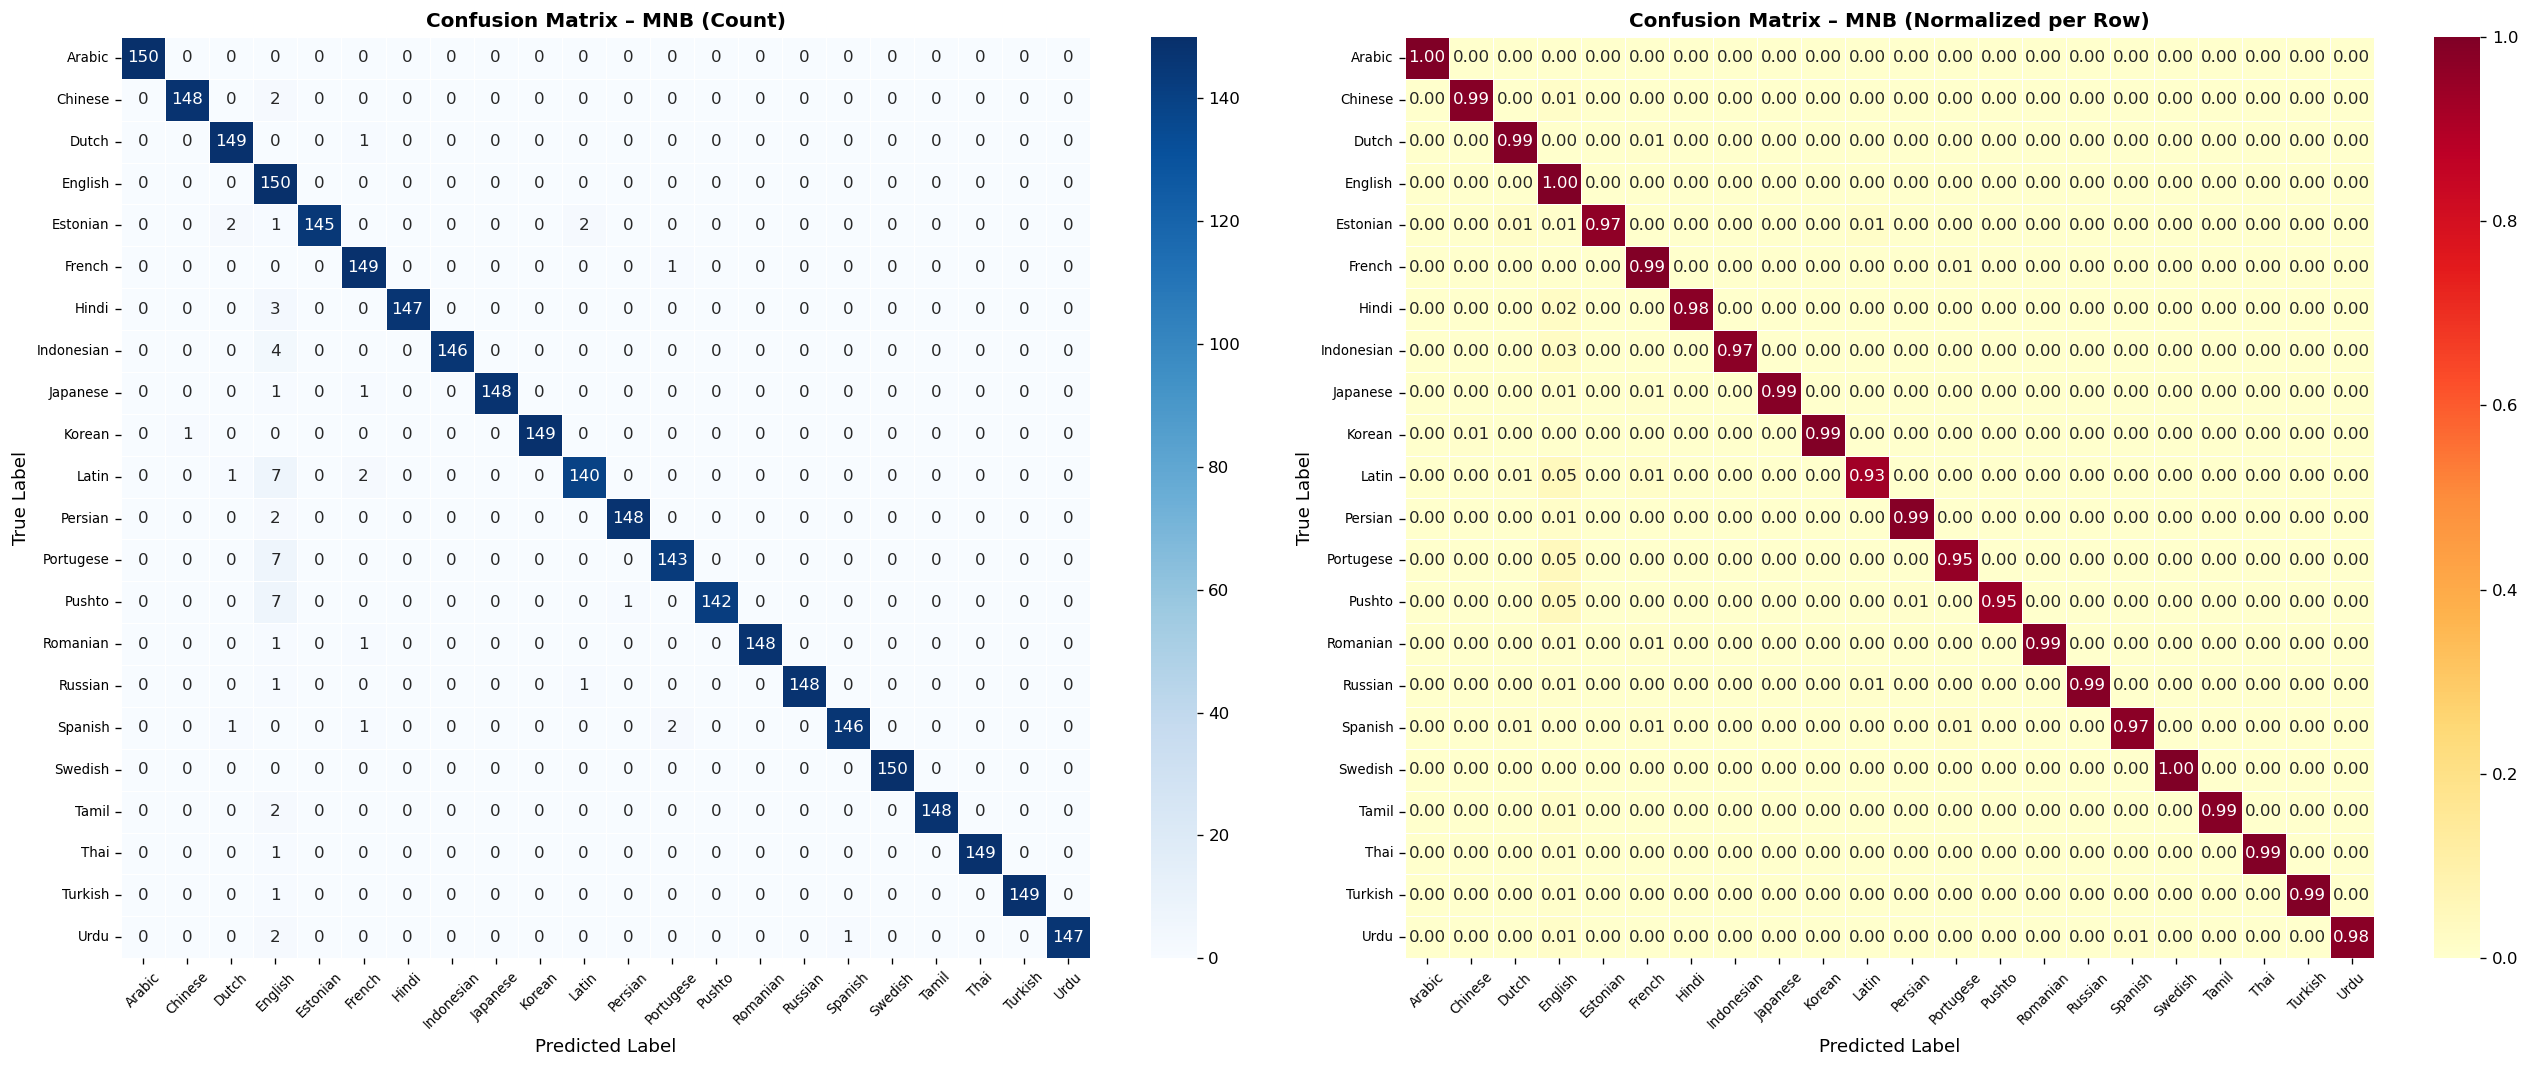

In [16]:
labels = sorted(df['language'].unique())

cm_mnb = confusion_matrix(y_test, y_test_pred_mnb, labels=labels)

# Normalisasi per baris (recall per kelas)
cm_norm = cm_mnb.astype(float) / cm_mnb.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Confusion matrix count
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix – MNB (Count)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Confusion matrix normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=labels, yticklabels=labels,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix – MNB (Normalized per Row)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('confusion_matrix_mnb.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Analisis pasangan bahasa yang sering tertukar
print('Analisis Kesalahan: Pasangan Bahasa yang Sering Tertukar\n')

errors = []
for i, true_lang in enumerate(labels):
    for j, pred_lang in enumerate(labels):
        if i != j and cm_mnb[i, j] > 0:
            errors.append({
                'True Language': true_lang,
                'Predicted As': pred_lang,
                'Count': cm_mnb[i, j],
                'Rate (%)': f"{cm_norm[i,j]*100:.1f}%"
            })

df_errors = pd.DataFrame(errors).sort_values('Count', ascending=False)
print(f'Top 15 Kesalahan Klasifikasi:')
print(df_errors.head(15).to_string(index=False))

Analisis Kesalahan: Pasangan Bahasa yang Sering Tertukar

Top 15 Kesalahan Klasifikasi:
True Language Predicted As  Count Rate (%)
    Portugese      English      7     4.7%
        Latin      English      7     4.7%
       Pushto      English      7     4.7%
   Indonesian      English      4     2.7%
        Hindi      English      3     2.0%
         Urdu      English      2     1.3%
        Tamil      English      2     1.3%
      Spanish    Portugese      2     1.3%
      Persian      English      2     1.3%
        Latin       French      2     1.3%
      Chinese      English      2     1.3%
     Estonian        Dutch      2     1.3%
     Estonian        Latin      2     1.3%
        Latin        Dutch      1     0.7%
      Russian        Latin      1     0.7%


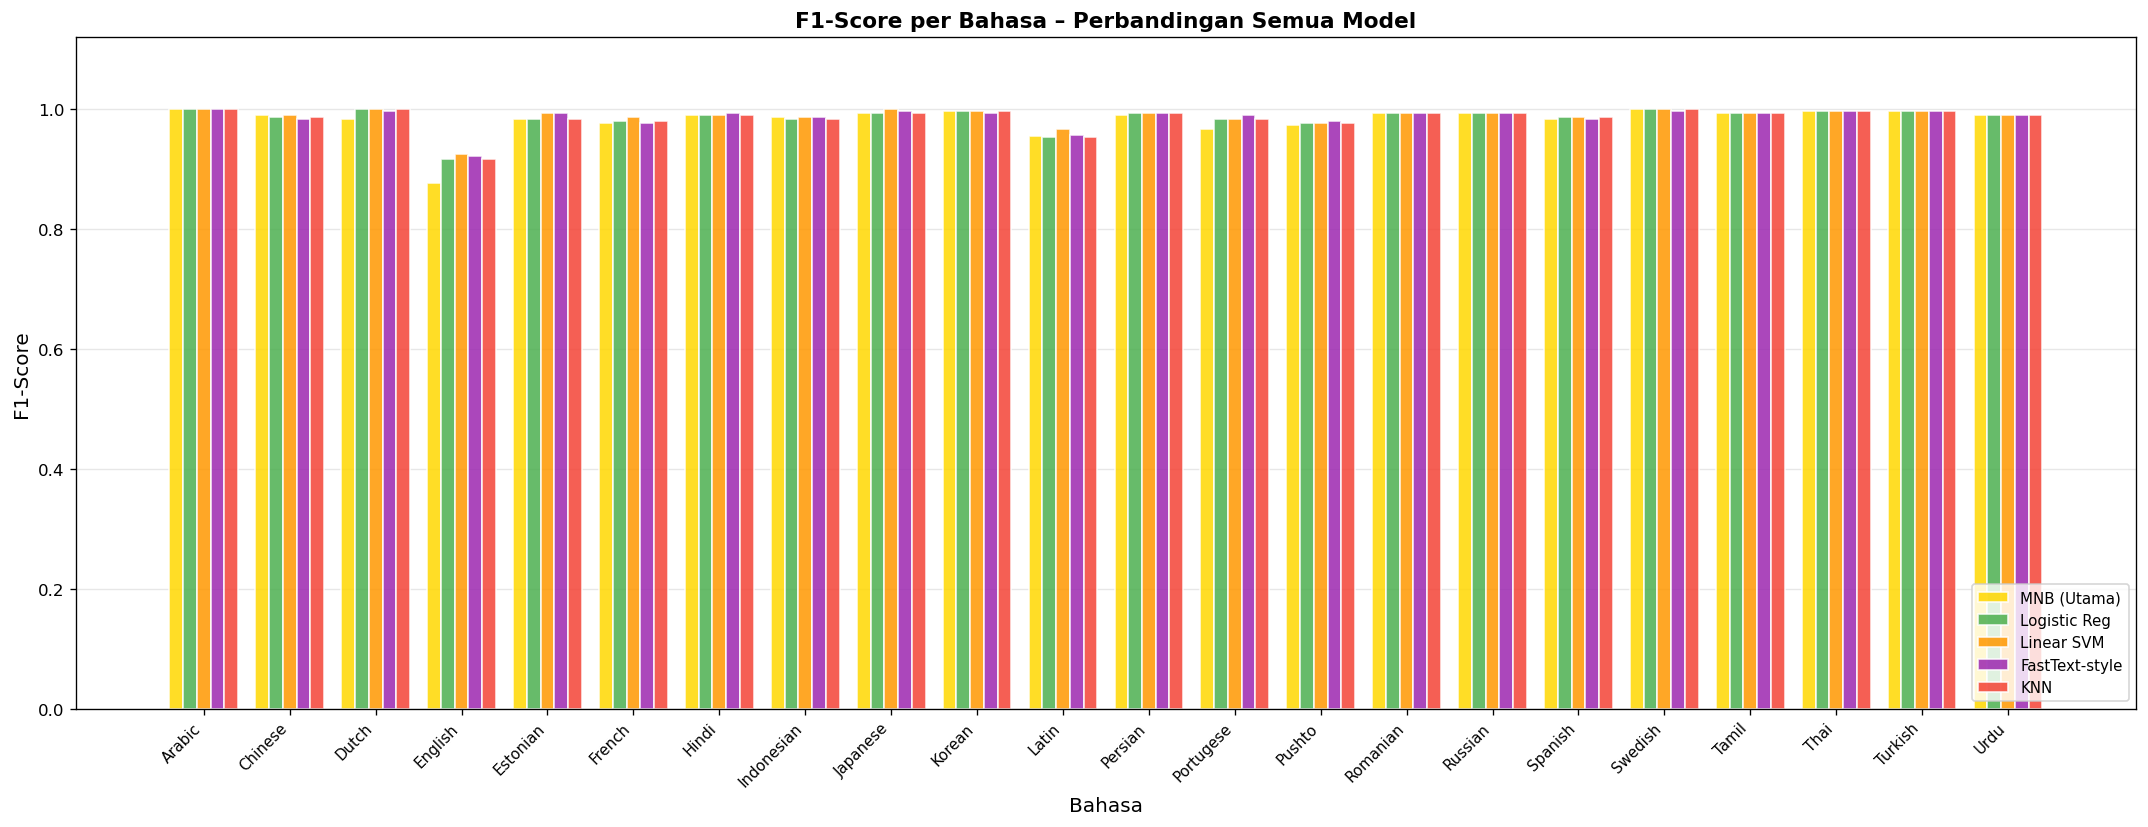

In [18]:
# F1-score per bahasa – perbandingan semua model
from sklearn.metrics import f1_score

f1_per_class = {}
preds_all = {
    'MNB (Utama)': y_test_pred_mnb,
    'Logistic Reg': y_test_pred_lr,
    'Linear SVM': y_test_pred_svm,
    'FastText-style': y_test_pred_fts,
    'KNN': y_test_pred_knn,
}

for model_name, y_pred in preds_all.items():
    f1_per_class[model_name] = f1_score(y_test, y_pred, labels=labels, average=None)

df_f1_class = pd.DataFrame(f1_per_class, index=labels)

fig, ax = plt.subplots(figsize=(18, 7))
x = np.arange(len(labels))
width = 0.16
offsets = [-2, -1, 0, 1, 2]
colors_model = ['gold', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for i, (model_name, col) in enumerate(zip(preds_all.keys(), colors_model)):
    ax.bar(x + offsets[i]*width, df_f1_class[model_name], width,
           label=model_name, color=col, alpha=0.85, edgecolor='white')

ax.set_xlabel('Bahasa', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('F1-Score per Bahasa – Perbandingan Semua Model', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('f1_per_language.png', dpi=150, bbox_inches='tight')
plt.show()

11. Simpan Model dan Pipeline

In [20]:
os.makedirs('saved_models', exist_ok=True)

# Simpan semua model dalam file saved_models
joblib.dump(mnb_pipeline, 'saved_models/mnb_language_detector.pkl')
joblib.dump(lr_pipeline, 'saved_models/logistic_regression_pipeline.pkl')
joblib.dump(svm_pipeline, 'saved_models/linear_svm_pipeline.pkl')
joblib.dump(fasttext_pipeline, 'saved_models/fasttext_style_pipeline.pkl')
joblib.dump(knn_pipeline, 'saved_models/knn_pipeline.pkl')

['saved_models/knn_pipeline.pkl']